In [1]:

import os
import io
import sys
import json
import pickle
import random
import warnings
from datetime import datetime, timedelta
from itertools import combinations
from multiprocessing import cpu_count

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D

import folium
from folium import plugins

import geopandas as gpd
import contextily as ctx

import holoviews as hv
from holoviews import opts
import hvplot
import hvplot.pandas 

import plotly.graph_objects as go

import pygeohash as pgh
import torch

from joblib import Parallel, delayed
from tqdm import tqdm

from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
from shapely.prepared import prep

from pyproj import Transformer

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from scipy.stats import multivariate_normal, chi2
from scipy.spatial import cKDTree

try:
    from IPython.display import display, HTML, IFrame
    _HAS_IPY = True
except Exception:
    _HAS_IPY = False
    import webbrowser

warnings.filterwarnings("ignore")


<MARK>
The following link needs to be updated in order to load the correct dataset of the AIS data. The link to download the dataset can be found in the README.md file of the preface directory.

In [2]:
%%time
csv_path = r"C:\Users\iliag\Desktop\MSc_DELFT\YEAR_2\Q2\Machine learning AI\Project\VS_CODE\Data\ProjectData_AIS_LA_2025.csv"

df = pd.read_csv(csv_path)

print(f"AIS dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns.")
df.head()


AIS dataset loaded: 4,056,967 rows × 17 columns.
CPU times: total: 6.14 s
Wall time: 6.15 s


,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo,TransceiverClass
0,366988970,2024-08-12T00:00:04,33.76708,-118.22046,0.0,271.9,121.0,LARCONA,NaN,WDC2171,31.0,0.0,21.0,7.0,3.2,31.0,A
1,367401030,2024-08-12T00:00:04,33.75408,-118.26853,0.1,16.3,88.0,DELTA BILLIE,IMO9562207,WDE8059,31.0,0.0,30.0,12.0,5.5,31.0,A
2,367452280,2024-08-12T00:00:04,33.73528,-118.26908,0.0,360.0,511.0,LAGUNA,NaN,WDL6144,52.0,0.0,60.0,19.0,2.5,52.0,A
3,367580930,2024-08-12T00:00:00,33.73759,-118.16589,23.3,116.1,511.0,TRIUMPHANT,IMO9759692,WDG8773,60.0,0.0,26.0,10.0,0.0,60.0,A
4,367691660,2024-08-12T00:00:07,33.74880,-118.11409,0.0,270.0,511.0,BIBI,NaN,WDI3764,37.0,7.0,19.0,5.0,0.0,30.0,A


1. Preprocess data like the paper (space, time, type, speed, heading, hourly)

In [3]:
%%time
time_col = "BaseDateTime"

df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col])

lat_min, lat_max = 33.60, 33.85
lon_min, lon_max = -118.45, -118.15
start = pd.Timestamp("2024-08-01 00:00:00")
end = pd.Timestamp("2024-08-31 00:00:00")

df["SOG"] = pd.to_numeric(df["SOG"], errors="coerce")

mask = (
    df["LAT"].between(lat_min, lat_max)
    & df["LON"].between(lon_min, lon_max)
    & df[time_col].ge(start)
    & df[time_col].lt(end)
    & (df["VesselType"].between(70, 79) | df["VesselType"].between(80, 89))
    & df["SOG"].lt(1)
)

df_f = df.loc[mask].copy()

df_f["Length"] = pd.to_numeric(df_f["Length"], errors="coerce")
df_f["Width"] = pd.to_numeric(df_f["Width"], errors="coerce")
df_f["Heading"] = pd.to_numeric(df_f["Heading"], errors="coerce")

df_f = df_f.loc[
    df_f["Length"].gt(0)
    & df_f["Width"].gt(0)
    & df_f["Heading"].notna()
    & df_f["Heading"].ne(511)
].copy()

df_f = df_f.sort_values(["MMSI", time_col])

d_heading = df_f.groupby("MMSI")["Heading"].diff().abs()
d_heading = d_heading.where(d_heading.isna(), np.minimum(d_heading, 360 - d_heading))
df_f = df_f.loc[d_heading.isna() | d_heading.le(10)].copy()

df_hour = (
    df_f.drop_duplicates(subset=["MMSI", time_col], keep="last")
    .set_index(time_col)
    .groupby("MMSI")
    .resample("1h")
    .last()
)

df_hour = df_hour.drop(columns=["MMSI"], errors="ignore").reset_index()

df_hour["LAT_original"] = df_hour["LAT"]
df_hour["LON_original"] = df_hour["LON"]

lat_mean = df_hour["LAT"].mean()
lat_std = df_hour["LAT"].std()
lon_mean = df_hour["LON"].mean()
lon_std = df_hour["LON"].std()

df_hour["LAT"] = (df_hour["LAT"] - lat_mean) / lat_std
df_hour["LON"] = (df_hour["LON"] - lon_mean) / lon_std

standardization_params = {
    "lat_mean": lat_mean,
    "lat_std": lat_std,
    "lon_mean": lon_mean,
    "lon_std": lon_std,
}


CPU times: total: 4.55 s
Wall time: 4.57 s


2. Convert to GeoDataFrame

In [4]:
%%time
cols_keep = [
    "MMSI",
    time_col,
    "LAT",
    "LON",
    "LAT_original",
    "LON_original",
    "SOG",
    "Heading",
    "VesselType",
    "Length",
    "Width",
]

df_clean = df_hour.loc[:, cols_keep].dropna(subset=["LAT", "LON"]).copy()

summary = pd.Series(
    {
        "rows": df_clean.shape[0],
        "cols": df_clean.shape[1],
        "memory_mb": df_clean.memory_usage(deep=True).sum() / 1e6,
        "lat_mean": df_clean["LAT"].mean(),
        "lat_std": df_clean["LAT"].std(),
        "lon_mean": df_clean["LON"].mean(),
        "lon_std": df_clean["LON"].std(),
        "lat_orig_min": df_clean["LAT_original"].min(),
        "lat_orig_max": df_clean["LAT_original"].max(),
        "lon_orig_min": df_clean["LON_original"].min(),
        "lon_orig_max": df_clean["LON_original"].max(),
        "length_min": df_clean["Length"].min(),
        "length_max": df_clean["Length"].max(),
        "width_min": df_clean["Width"].min(),
        "width_max": df_clean["Width"].max(),
    }
)

summary


CPU times: total: 15.6 ms
Wall time: 5.83 ms


rows            2.679200e+04
cols            1.100000e+01
memory_mb       2.572032e+00
lat_mean       -3.498357e-13
lat_std         1.000000e+00
lon_mean       -3.132414e-13
lon_std         1.000000e+00
lat_orig_min    3.369754e+01
lat_orig_max    3.377588e+01
lon_orig_min   -1.182817e+02
lon_orig_max   -1.181500e+02
length_min      4.500000e+01
length_max      4.000000e+02
width_min       1.500000e+01
width_max       6.000000e+01
dtype: float64

In [5]:
%%time
output_filename = "preprocessed_la_port_cargo_tanker.csv"
df_clean.to_csv(output_filename, index=False)

with open("standardization_params.json", "w") as f:
    json.dump(standardization_params, f, indent=2)

pd.Series(
    {
        "output_csv": output_filename,
        "rows": df_clean.shape[0],
        "cols": df_clean.shape[1],
        "unique_vessels": df_clean["MMSI"].nunique(),
        "date_range_days": (df_clean[time_col].max() - df_clean[time_col].min()).days,
        "saved_columns": list(df_clean.columns),
    }
)


CPU times: total: 188 ms
Wall time: 184 ms


output_csv                     preprocessed_la_port_cargo_tanker.csv
rows                                                           26792
cols                                                              11
unique_vessels                                                   363
date_range_days                                                   29
saved_columns      [MMSI, BaseDateTime, LAT, LON, LAT_original, L...
dtype: object

4. Visualize points over Port of LA map

CPU times: total: 0 ns
Wall time: 0 ns


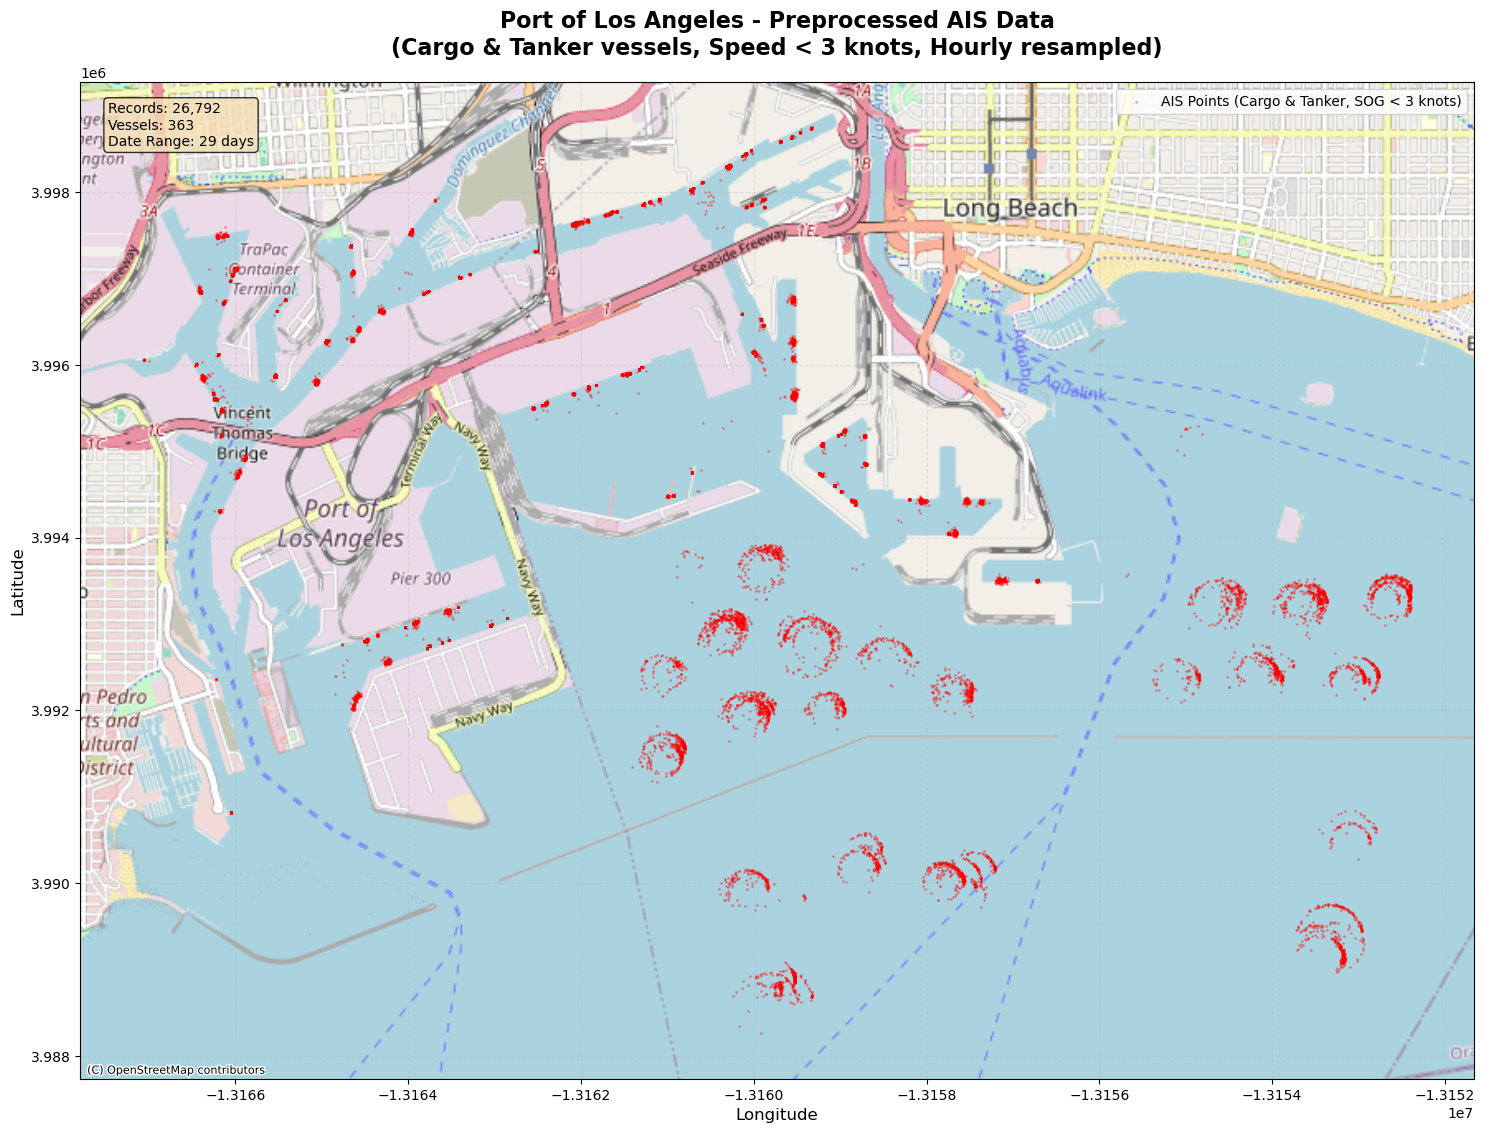

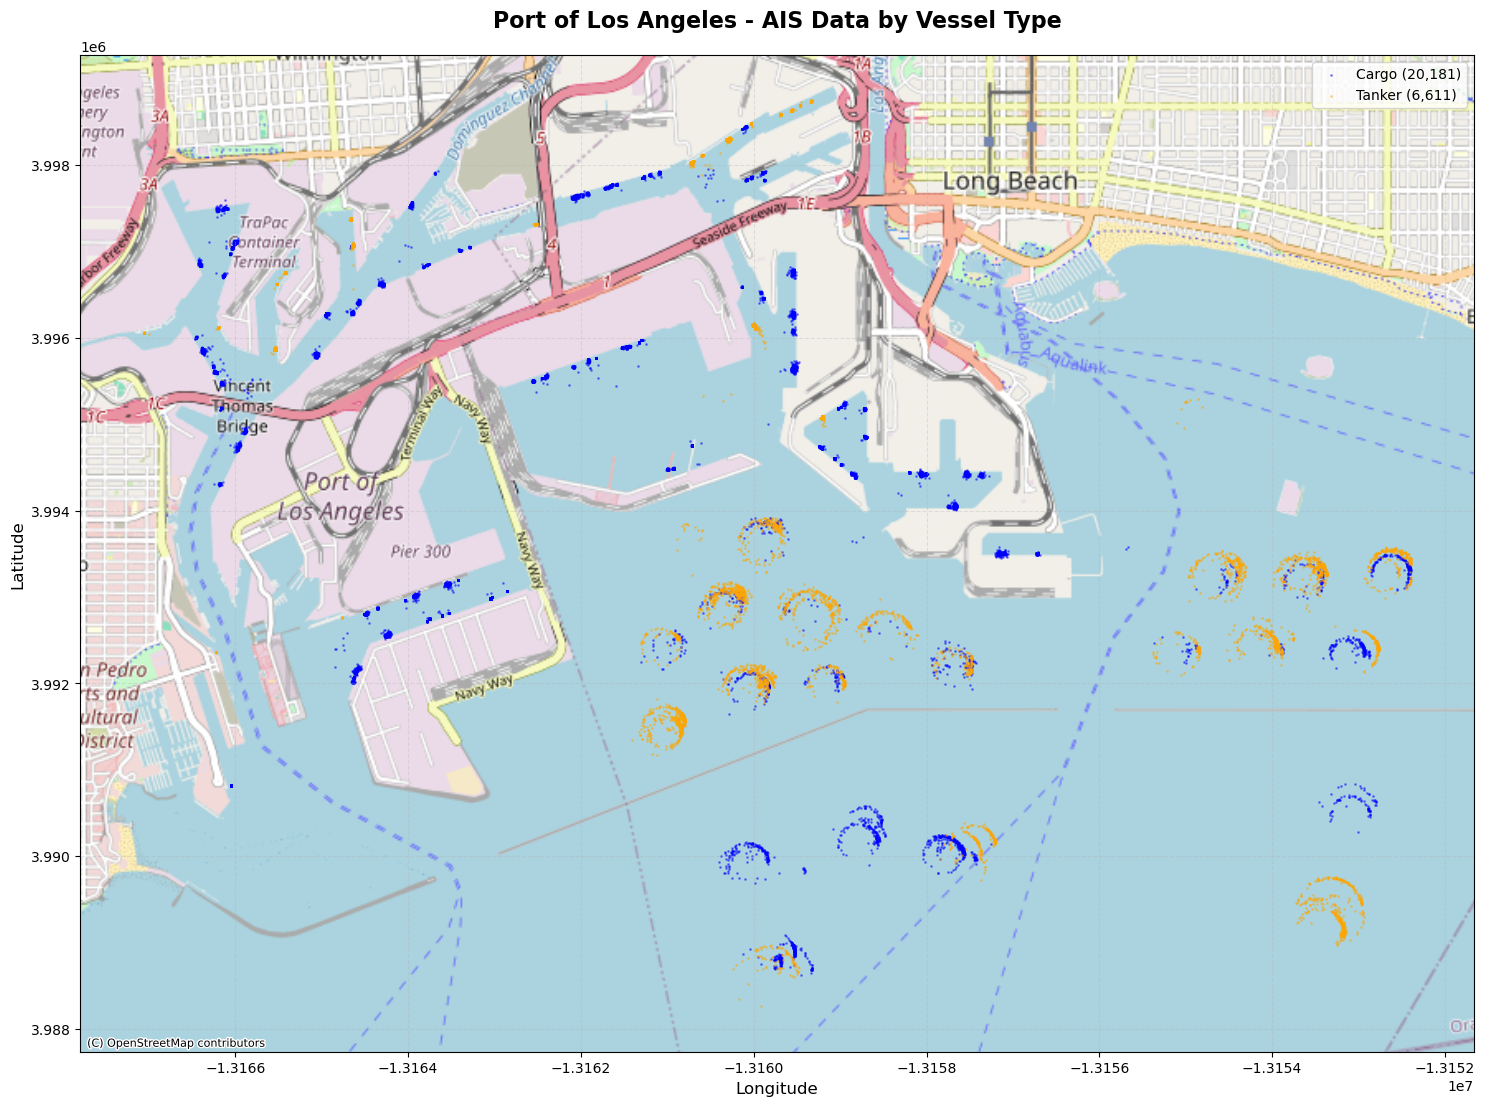

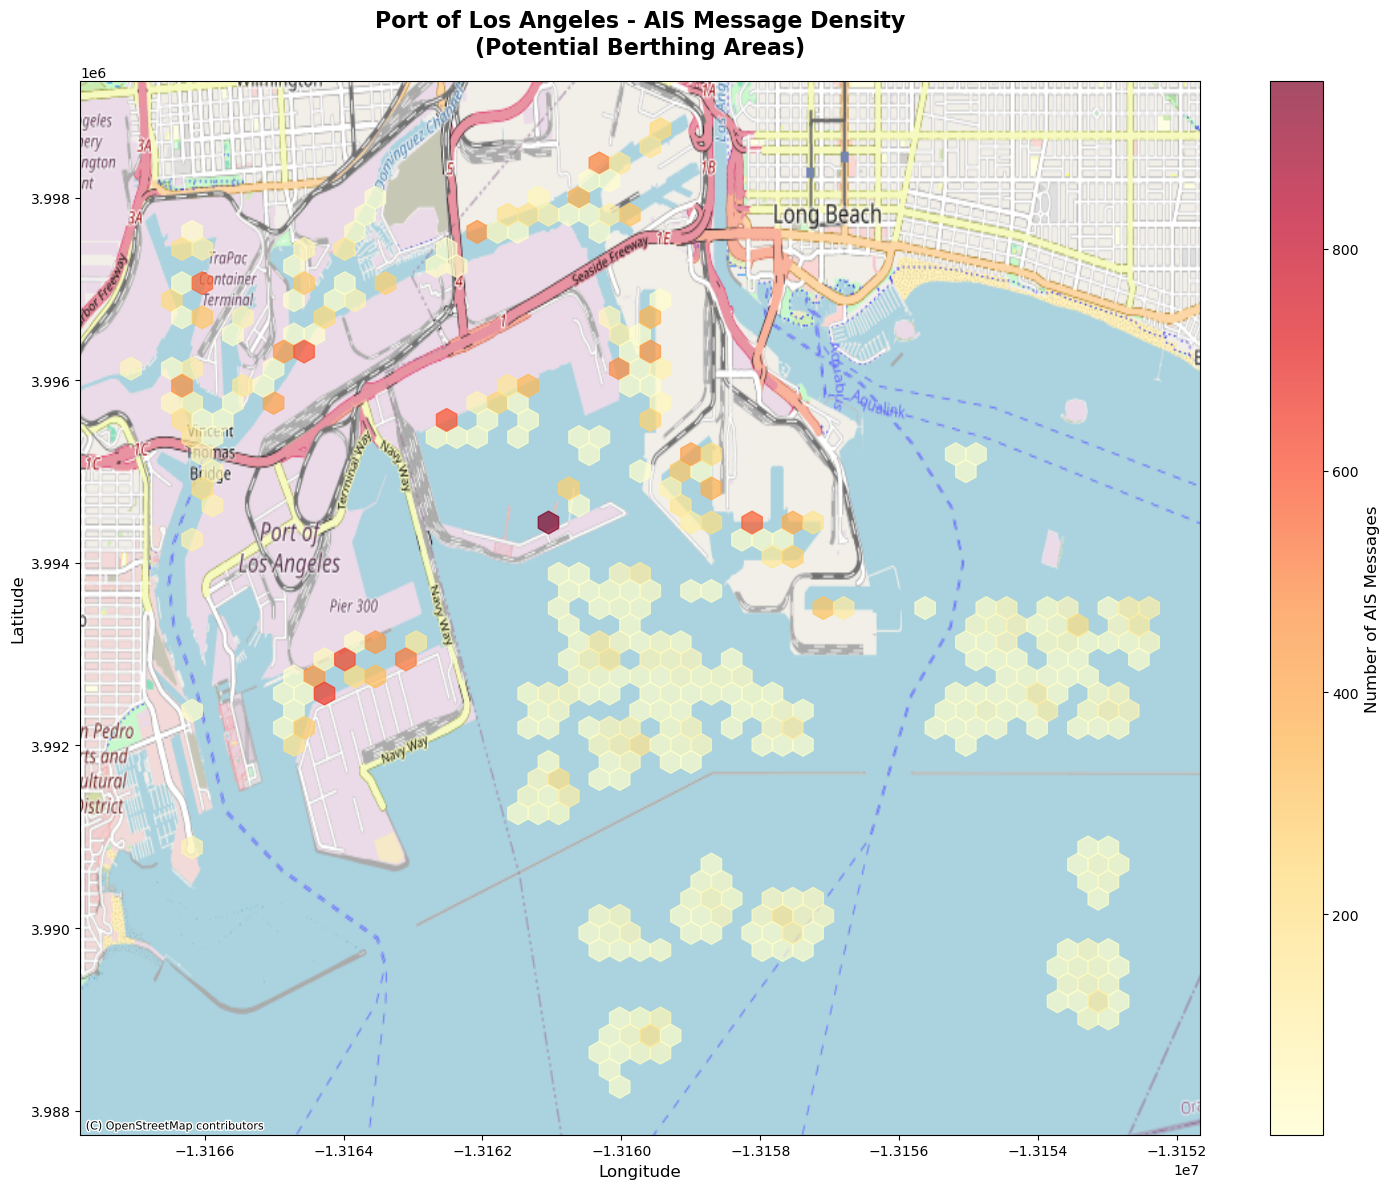

In [6]:
%time
time_col = "BaseDateTime"

gdf_viz = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean["LON_original"], df_clean["LAT_original"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

records = len(df_clean)
vessels = df_clean["MMSI"].nunique()
date_range_days = (df_clean[time_col].max() - df_clean[time_col].min()).days

fig, ax = plt.subplots(figsize=(15, 12))
gdf_viz.plot(
    ax=ax,
    markersize=1,
    alpha=0.3,
    color="red",
    label="AIS Points (Cargo & Tanker, SOG < 3 knots)",
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=13, attribution_size=8)

ax.set_title(
    "Port of Los Angeles - Preprocessed AIS Data\n"
    "(Cargo & Tanker vessels, Speed < 3 knots, Hourly resampled)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")

ax.text(
    0.02,
    0.98,
    f"Records: {records:,}\nVessels: {vessels}\nDate Range: {date_range_days} days",
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

plt.tight_layout()
plt.savefig("port_la_ais_overview.png", dpi=300, bbox_inches="tight")
plt.show()

cargo = gdf_viz[gdf_viz["VesselType"].between(70, 79)]
tanker = gdf_viz[gdf_viz["VesselType"].between(80, 89)]

fig, ax = plt.subplots(figsize=(15, 12))
cargo.plot(ax=ax, markersize=1, alpha=0.4, color="blue", label=f"Cargo ({len(cargo):,})")
tanker.plot(ax=ax, markersize=1, alpha=0.4, color="orange", label=f"Tanker ({len(tanker):,})")

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=13, attribution_size=8)

ax.set_title("Port of Los Angeles - AIS Data by Vessel Type", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("port_la_ais_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(15, 12))
x = gdf_viz.geometry.x
y = gdf_viz.geometry.y

hexbin = ax.hexbin(x, y, gridsize=50, cmap="YlOrRd", mincnt=1, alpha=0.7)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=13, attribution_size=8)

cb = plt.colorbar(hexbin, ax=ax)
cb.set_label("Number of AIS Messages", fontsize=12)

ax.set_title(
    "Port of Los Angeles - AIS Message Density\n(Potential Berthing Areas)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

plt.tight_layout()
plt.savefig("port_la_ais_density.png", dpi=300, bbox_inches="tight")
plt.show()


4 WAY SPLIT

In [7]:
df_preprocessed = pd.read_csv("preprocessed_la_port_cargo_tanker.csv")

df_preprocessed["BaseDateTime"] = pd.to_datetime(df_preprocessed["BaseDateTime"], errors="coerce")
df_preprocessed["LAT"] = pd.to_numeric(df_preprocessed["LAT"], errors="coerce")
df_preprocessed["LON"] = pd.to_numeric(df_preprocessed["LON"], errors="coerce")
df_preprocessed = df_preprocessed.dropna(subset=["LAT", "LON"]).copy()

vessel_counts = df_preprocessed.groupby("MMSI").size().sort_values(ascending=False)

split_ids = (np.arange(len(vessel_counts)) % 4).astype(int)
split_assignment = pd.Series(split_ids, index=vessel_counts.index)

df_preprocessed["split"] = df_preprocessed["MMSI"].map(split_assignment).astype(int)

splits = [df_preprocessed.loc[df_preprocessed["split"].eq(i)].copy() for i in range(4)]
split_0, split_1, split_2, split_3 = splits

print(f"Split 0: {len(split_0):,} rows, {split_0['MMSI'].nunique()} vessels")
print(f"Split 1: {len(split_1):,} rows, {split_1['MMSI'].nunique()} vessels")
print(f"Split 2: {len(split_2):,} rows, {split_2['MMSI'].nunique()} vessels")
print(f"Split 3: {len(split_3):,} rows, {split_3['MMSI'].nunique()} vessels")


Split 0: 7,020 rows, 91 vessels
Split 1: 6,803 rows, 91 vessels
Split 2: 6,597 rows, 91 vessels
Split 3: 6,372 rows, 90 vessels


----------------------------------

**K-means**

In [8]:
K_MIN = 40
K_MAX = 101
RANDOM_SEED = 42
MAX_ITER = 1000
N_INIT = 20
PLATEAU_THRESHOLD = 0.01
PLATEAU_COUNT = 3
N_JOBS = -1

splits_for_kmeans = [split_0, split_1, split_2, split_3]
K_RANGE = range(K_MIN, K_MAX)


def kmeans_single_run(data: np.ndarray, K: int, max_iter: int, random_state: int):
    np.random.seed(random_state)
    N = data.shape[0]

    mu = data[np.random.choice(N, K, replace=False)].copy()
    prev_labels = None

    for iteration in range(max_iter):
        distances = np.sum((data[:, None, :] - mu[None, :, :]) ** 2, axis=2)
        labels = np.argmin(distances, axis=1)

        if prev_labels is not None and np.array_equal(labels, prev_labels):
            break
        prev_labels = labels

        for k in range(K):
            mask = labels == k
            if np.any(mask):
                mu[k] = data[mask].mean(axis=0)

    J = distances[np.arange(N), labels].sum()
    return mu, labels, J, iteration


def kmeans_best_of_n_parallel(
    data: np.ndarray,
    K: int,
    n_init: int = N_INIT,
    max_iter: int = MAX_ITER,
    base_seed: int = RANDOM_SEED,
    n_jobs: int = N_JOBS,
):
    seeds = [base_seed + run * 1000 + K for run in range(n_init)]
    results = Parallel(n_jobs=n_jobs)(
        delayed(kmeans_single_run)(data, K, max_iter, seed) for seed in seeds
    )
    best_idx = int(np.argmin([r[2] for r in results]))
    return results[best_idx]


def run_single_split_parallel(data: np.ndarray, K_range, split_idx: int, n_jobs: int = N_JOBS):
    results = Parallel(n_jobs=n_jobs)(
        delayed(kmeans_best_of_n_parallel)(data, K, N_INIT, MAX_ITER, RANDOM_SEED, 1)
        for K in tqdm(K_range, desc=f"Split {split_idx}", position=split_idx)
    )

    summary_df = pd.DataFrame(
        {
            "K": list(K_range),
            "final_J": [r[2] for r in results],
            "converged_iteration": [r[3] for r in results],
        }
    ).sort_values("K", ignore_index=True)

    all_results = {
        K: {"means": r[0], "labels": r[1], "J": r[2]}
        for K, r in zip(list(K_range), results)
    }

    return summary_df, all_results


def process_split(split_idx: int, split_df: pd.DataFrame, K_range):
    data = split_df[["LON", "LAT"]].to_numpy()
    summary_df, results = run_single_split_parallel(data, K_range, split_idx, n_jobs=1)
    return {
        "split_idx": split_idx,
        "summary": summary_df,
        "all_results": results,
        "n_points": int(data.shape[0]),
        "n_vessels": int(split_df["MMSI"].nunique()),
    }


def find_valid_K_range(all_split_results, K_range, threshold: float = PLATEAU_THRESHOLD, count: int = PLATEAU_COUNT):
    K_values = np.array(list(K_range))
    n_splits = len(all_split_results)

    improvements = np.zeros((n_splits, len(K_values) - 1), dtype=float)
    for split_idx in range(n_splits):
        J_vals = all_split_results[split_idx]["summary"]["final_J"].to_numpy()
        improvements[split_idx] = (J_vals[:-1] - J_vals[1:]) / J_vals[:-1]

    all_below = np.all(improvements < threshold, axis=0)

    max_valid_idx = len(K_values) - 1
    consecutive = 0
    for i, ok in enumerate(all_below):
        consecutive = consecutive + 1 if ok else 0
        if consecutive >= count:
            max_valid_idx = i + 1 - count
            break

    return int(K_values[max_valid_idx]), improvements


def find_optimal_K(all_split_results, K_range, max_valid_K: int):
    K_values = np.array(list(K_range))
    valid_mask = K_values <= max_valid_K
    if not np.any(valid_mask):
        return {"optimal_K": int(K_values[0]), "max_valid_K": int(max_valid_K)}

    n_splits = len(all_split_results)
    normalized_J = np.zeros((n_splits, len(K_values)), dtype=float)

    for split_idx in range(n_splits):
        J_vals = all_split_results[split_idx]["summary"]["final_J"].to_numpy()
        denom = J_vals.max() - J_vals.min()
        normalized_J[split_idx] = (J_vals - J_vals.min()) / (denom if denom != 0 else 1.0)

    variance_per_K = np.var(normalized_J, axis=0)
    optimal_idx = int(np.argmin(variance_per_K[valid_mask]))
    optimal_K = int(K_values[valid_mask][optimal_idx])
    full_idx = int(np.where(K_values == optimal_K)[0][0])

    return {
        "optimal_K": optimal_K,
        "max_valid_K": int(max_valid_K),
        "variance": float(variance_per_K[full_idx]),
        "mean_normalized_J": float(np.mean(normalized_J[:, full_idx])),
        "normalized_J_values": normalized_J[:, full_idx],
    }


outer_jobs = min(4, cpu_count())
split_results_list = Parallel(n_jobs=outer_jobs)(
    delayed(process_split)(split_idx, split_df, K_RANGE)
    for split_idx, split_df in enumerate(splits_for_kmeans)
)

all_split_results = {res["split_idx"]: res for res in split_results_list}

max_valid_K, improvements = find_valid_K_range(all_split_results, K_RANGE)
metrics = find_optimal_K(all_split_results, K_RANGE, max_valid_K)

OPTIMAL_K = metrics["optimal_K"]
KMEANS_RESULTS = {
    f"split_{i}": {
        "K": OPTIMAL_K,
        "means": all_split_results[i]["all_results"][OPTIMAL_K]["means"],
        "labels": all_split_results[i]["all_results"][OPTIMAL_K]["labels"],
        "J": all_split_results[i]["all_results"][OPTIMAL_K]["J"],
    }
    for i in range(4)
}

pd.Series(
    {
        "K_min": K_MIN,
        "K_max_exclusive": K_MAX,
        "n_init": N_INIT,
        "cpu_cores": cpu_count(),
        "max_valid_K": max_valid_K,
        "optimal_K": OPTIMAL_K,
        "variance_at_optimal_K": metrics.get("variance", np.nan),
    }
)


K_min                     40.000000
K_max_exclusive          101.000000
n_init                    20.000000
cpu_cores                 16.000000
max_valid_K              100.000000
optimal_K                 80.000000
variance_at_optimal_K      0.000019
dtype: float64

Plot the Kmeans Clusters

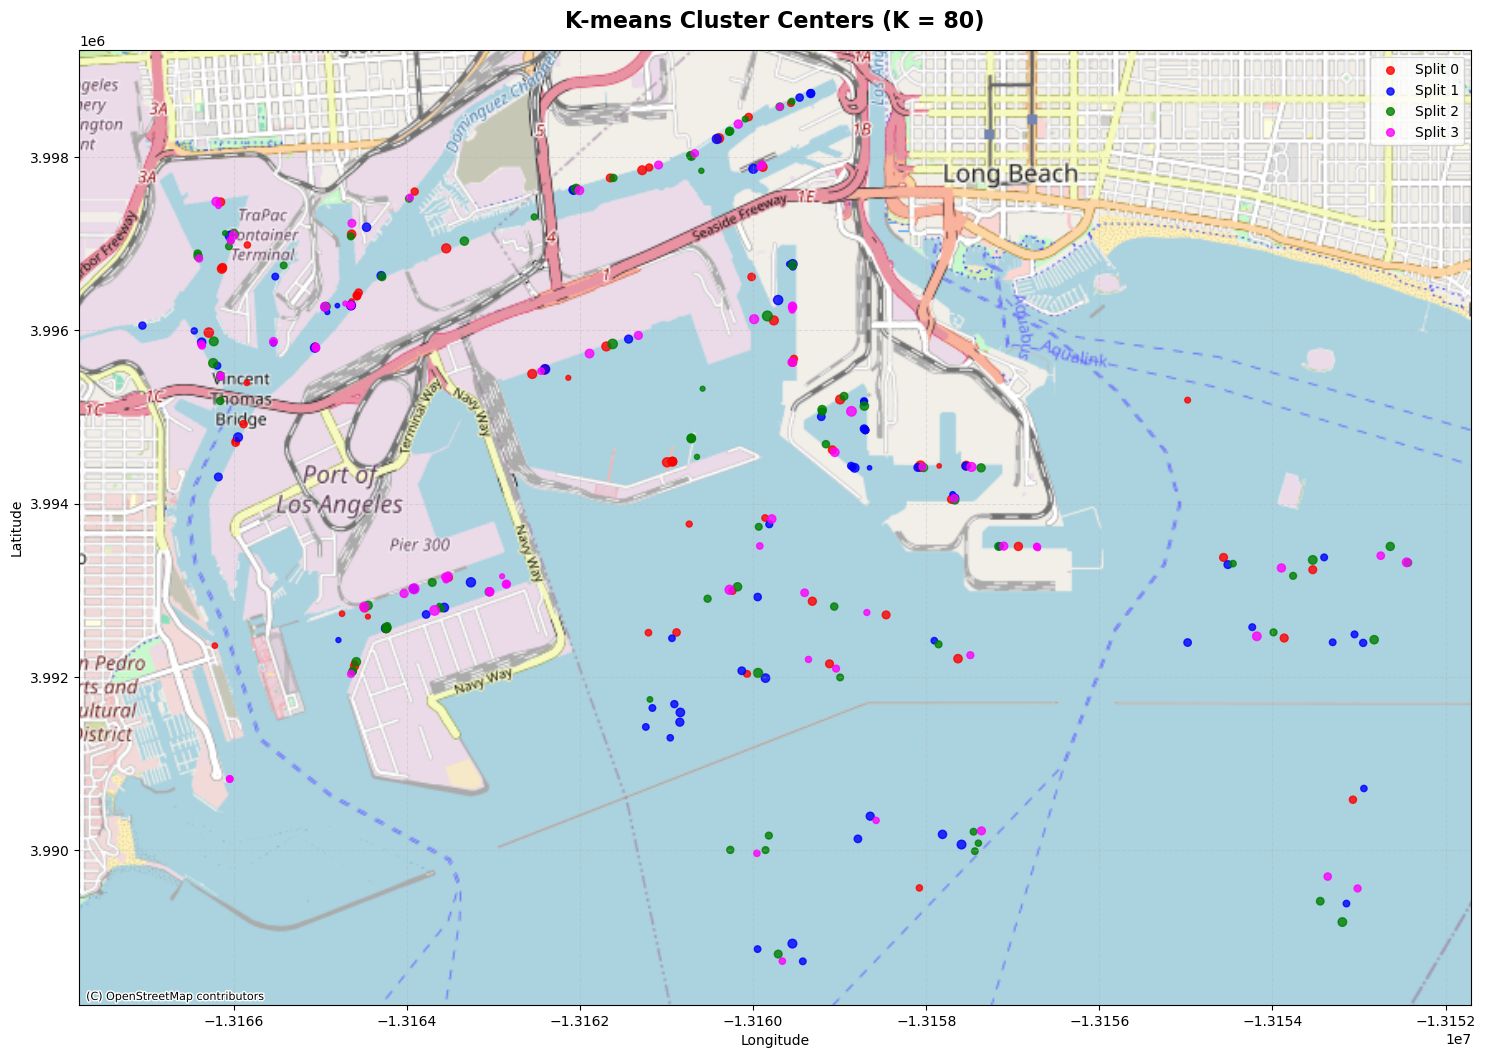

In [9]:
with open("standardization_params.json", "r") as f:
    std_params = json.load(f)

lon_mean, lon_std = std_params["lon_mean"], std_params["lon_std"]
lat_mean, lat_std = std_params["lat_mean"], std_params["lat_std"]

all_centers = []
for split_idx in range(4):
    res = KMEANS_RESULTS[f"split_{split_idx}"]
    centers_std = res["means"]  # standardized [LON, LAT]
    K = res["K"]

    # un-standardize
    centers_lon = centers_std[:, 0] * lon_std + lon_mean
    centers_lat = centers_std[:, 1] * lat_std + lat_mean

    labels = res["labels"]
    for k in range(K):
        n_points = int(np.sum(labels == k))
        all_centers.append(
            {
                "split_idx": split_idx,
                "cluster_id": k,
                "lon": float(centers_lon[k]),
                "lat": float(centers_lat[k]),
                "n_points": n_points,
            }
        )

centers_df = pd.DataFrame(all_centers)
gdf_centers = gpd.GeoDataFrame(
    centers_df,
    geometry=gpd.points_from_xy(centers_df["lon"], centers_df["lat"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

split_colors = {0: "red", 1: "blue", 2: "green", 3: "magenta"}
gdf_centers["color"] = gdf_centers["split_idx"].map(split_colors)

sizes = np.sqrt(gdf_centers["n_points"].to_numpy())
sizes = 10 + 40 * (sizes - sizes.min()) / (sizes.max() - sizes.min() + 1e-12)

fig, ax = plt.subplots(figsize=(15, 12))

for split_idx, g in gdf_centers.groupby("split_idx", sort=True):
    g.plot(
        ax=ax,
        markersize=sizes[g.index],
        alpha=0.8,
        color=split_colors[int(split_idx)],
        label=f"Split {int(split_idx)}",
    )

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=13, attribution_size=8)

ax.set_title(f"K-means Cluster Centers (K = {OPTIMAL_K})", fontsize=16, fontweight="bold", pad=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


Add Dimensions of vessels

In [10]:
for split_df in (split_0, split_1, split_2, split_3):
    split_df["DimensionA"] = split_df["Length"] / 2
    split_df["DimensionB"] = split_df["Length"] / 2
    split_df["DimensionC"] = split_df["Width"] / 2
    split_df["DimensionD"] = split_df["Width"] / 2


Spatial Augmentation

In [11]:
with open("standardization_params.json", "r") as f:
    std_params = json.load(f)

def generate_augmented_points(df: pd.DataFrame, n_points: int = 10) -> pd.DataFrame:
    augmented = []
    skipped = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Augmenting", unit="msg"):
        heading = row["Heading"]
        if pd.isna(heading) or heading < 0 or heading > 360:
            skipped += 1
            continue

        dim_a = row["DimensionA"]
        dim_b = row["DimensionB"]
        dim_c = row["DimensionC"]
        dim_d = row["DimensionD"]

        if any(pd.isna([dim_a, dim_b, dim_c, dim_d])) or any(v <= 0 for v in (dim_a, dim_b, dim_c, dim_d)):
            skipped += 1
            continue

        if (dim_a + dim_b) > 500 or (dim_c + dim_d) > 100:
            skipped += 1
            continue

        lat_orig = row["LAT_original"]
        lon_orig = row["LON_original"]

        heading_rad = np.radians(heading)
        meters_per_degree_lat = 111000.0
        meters_per_degree_lon = 111000.0 * np.cos(np.radians(lat_orig))

        max_offset_lat = ((dim_a + dim_b) * 1.5) / meters_per_degree_lat
        max_offset_lon = ((dim_c + dim_d) * 1.5) / meters_per_degree_lon

        for _ in range(n_points):
            x_local = np.random.uniform(-dim_b, dim_a)
            y_local = np.random.uniform(-dim_c, dim_d)

            x_global = x_local * np.sin(heading_rad) + y_local * np.cos(heading_rad)
            y_global = x_local * np.cos(heading_rad) - y_local * np.sin(heading_rad)

            lat_offset_deg = y_global / meters_per_degree_lat
            lon_offset_deg = x_global / meters_per_degree_lon

            new_lat_orig = lat_orig + lat_offset_deg
            new_lon_orig = lon_orig + lon_offset_deg

            if (abs(new_lat_orig - lat_orig) > max_offset_lat) or (abs(new_lon_orig - lon_orig) > max_offset_lon):
                continue

            aug = row.copy()
            aug["LAT_original"] = new_lat_orig
            aug["LON_original"] = new_lon_orig
            aug["LAT"] = (new_lat_orig - std_params["lat_mean"]) / std_params["lat_std"]
            aug["LON"] = (new_lon_orig - std_params["lon_mean"]) / std_params["lon_std"]
            aug["is_augmented"] = True
            augmented.append(aug)

        orig = row.copy()
        orig["is_augmented"] = False
        augmented.append(orig)

    if skipped:
        print(f"Skipped {skipped} points due to invalid heading/dimensions")

    return pd.DataFrame(augmented)


N_POINTS_TRAINING = 10

split_0_augmented = generate_augmented_points(split_0, n_points=N_POINTS_TRAINING)
split_1_augmented = generate_augmented_points(split_1, n_points=N_POINTS_TRAINING)
split_2_augmented = generate_augmented_points(split_2, n_points=N_POINTS_TRAINING)
split_3_augmented = generate_augmented_points(split_3, n_points=N_POINTS_TRAINING)

splits_augmented = [split_0_augmented, split_1_augmented, split_2_augmented, split_3_augmented]


Augmenting: 100%|██████████| 6372/6372 [00:14<00:00, 430.14msg/s]


VALIDATION MAP: ORIGINAL + AUGMENTED DATA

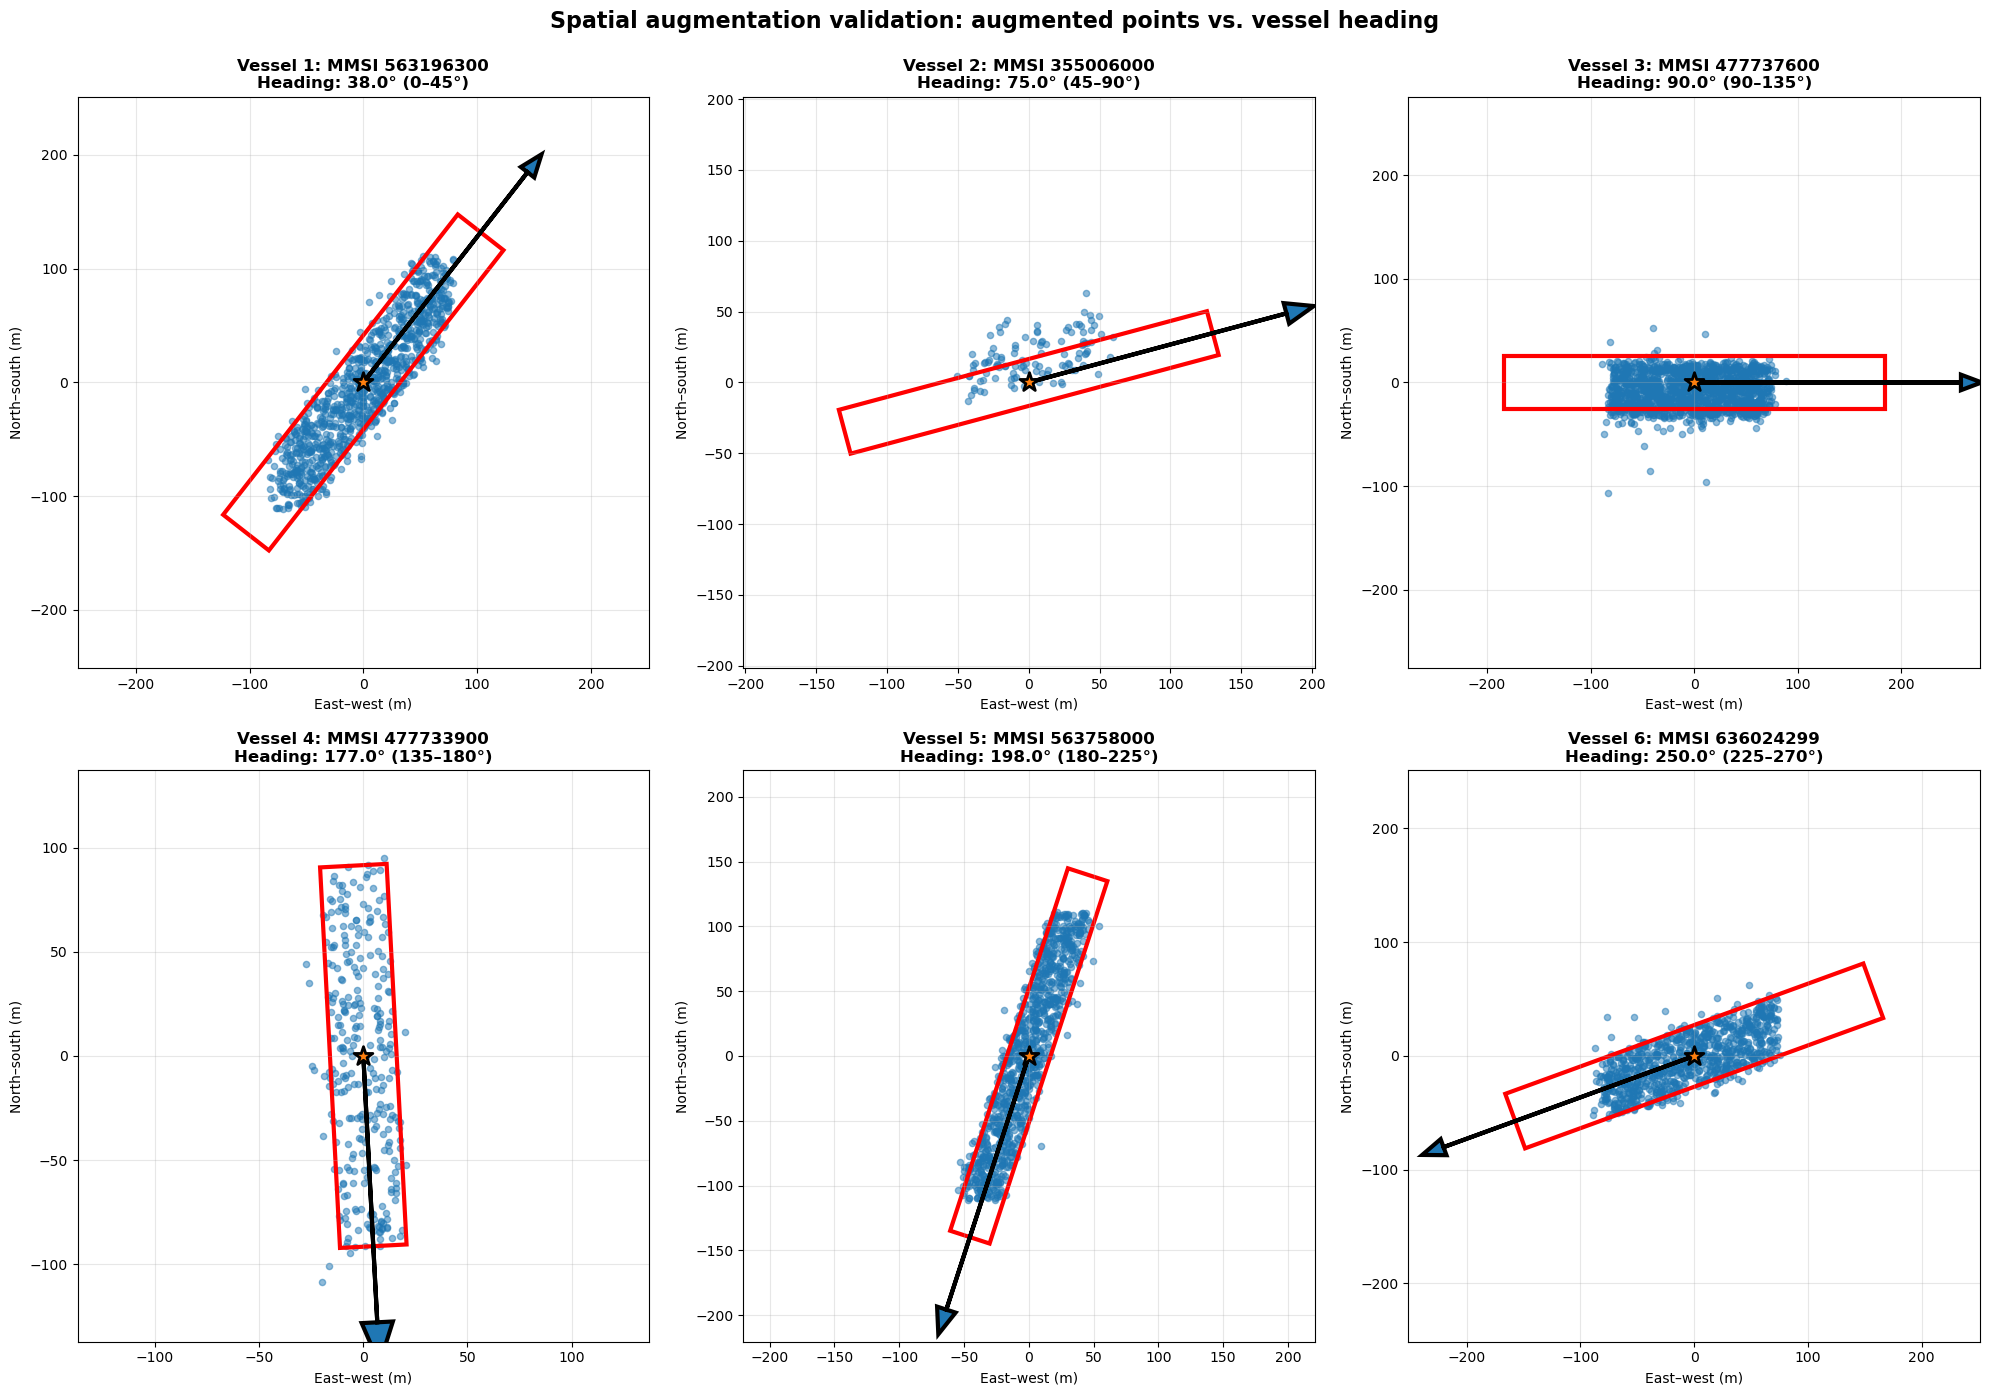

CPU times: total: 969 ms
Wall time: 935 ms


split_0    6.951282
split_1    6.489049
split_2    6.885706
split_3    6.342593
dtype: float64

In [12]:
%%time
original_points = split_0_augmented.loc[~split_0_augmented["is_augmented"]].copy()

heading_ranges = [
    (0, 45, "0–45°"),
    (45, 90, "45–90°"),
    (90, 135, "90–135°"),
    (135, 180, "135–180°"),
    (180, 225, "180–225°"),
    (225, 270, "225–270°"),
    (270, 315, "270–315°"),
    (315, 360, "315–360°"),
]

vessels_to_plot = []
for h_min, h_max, label in heading_ranges:
    candidates = original_points.loc[original_points["Heading"].between(h_min, h_max, inclusive="left")]
    if len(candidates):
        vessels_to_plot.append((candidates.sample(1).iloc[0], label))
    if len(vessels_to_plot) >= 6:
        break

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

def to_meters(lat, lon, lat_ref, lon_ref):
    lat_m = (lat - lat_ref) * 111000.0
    lon_m = (lon - lon_ref) * 111000.0 * np.cos(np.radians(lat_ref))
    return lon_m, lat_m

for idx, (vessel, heading_label) in enumerate(vessels_to_plot[:6]):
    ax = axes[idx]

    mmsi = vessel["MMSI"]
    heading = vessel["Heading"]
    lat_orig = vessel["LAT_original"]
    lon_orig = vessel["LON_original"]

    dim_a = vessel["DimensionA"]
    dim_b = vessel["DimensionB"]
    dim_c = vessel["DimensionC"]
    dim_d = vessel["DimensionD"]

    vessel_data = split_0_augmented.loc[
        (split_0_augmented["MMSI"] == mmsi)
        & (np.abs(split_0_augmented["LAT_original"] - lat_orig) < 0.001)
        & (np.abs(split_0_augmented["LON_original"] - lon_orig) < 0.001)
    ]

    augmented = vessel_data.loc[vessel_data["is_augmented"]]

    if len(augmented):
        aug_x, aug_y = to_meters(
            augmented["LAT_original"].to_numpy(),
            augmented["LON_original"].to_numpy(),
            lat_orig,
            lon_orig,
        )
        ax.scatter(aug_x, aug_y, s=20, alpha=0.5, label="Augmented points")

    ax.scatter([0], [0], s=200, marker="*", edgecolors="black", linewidths=2, label="Original AIS", zorder=10)

    vessel_length = dim_a + dim_b
    vessel_width = dim_c + dim_d

    rect = Rectangle(
        (-dim_b, -dim_c),
        vessel_length,
        vessel_width,
        linewidth=3,
        edgecolor="red",
        facecolor="none",
        label="Vessel footprint",
    )
    rect.set_transform(Affine2D().rotate_deg(90 - heading) + ax.transData)
    ax.add_patch(rect)

    arrow_length = max(vessel_length, vessel_width) * 0.7
    heading_rad = np.radians(heading)
    ax.arrow(
        0,
        0,
        arrow_length * np.sin(heading_rad),
        arrow_length * np.cos(heading_rad),
        head_width=15,
        head_length=20,
        linewidth=3,
        zorder=5,
    )

    ax.set_xlabel("East–west (m)")
    ax.set_ylabel("North–south (m)")
    ax.set_title(f"Vessel {idx+1}: MMSI {mmsi}\nHeading: {heading:.1f}° ({heading_label})", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

    max_range = max(vessel_length, vessel_width) * 1.5
    ax.set_xlim(-max_range / 2, max_range / 2)
    ax.set_ylim(-max_range / 2, max_range / 2)

for j in range(len(vessels_to_plot), 6):
    axes[j].axis("off")

plt.suptitle("Spatial augmentation validation: augmented points vs. vessel heading", fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

ratios = {}
for i, split in enumerate([split_0_augmented, split_1_augmented, split_2_augmented, split_3_augmented]):
    n_orig = int((~split["is_augmented"]).sum())
    n_aug = int((split["is_augmented"]).sum())
    ratios[f"split_{i}"] = (n_aug / n_orig) if n_orig else np.nan

pd.Series(ratios)


GEOHASH ENCODING

In [13]:
%%time
GEOHASH_PRECISION = 9

def circular_mean_degrees(angles: pd.Series) -> float:
    angles_rad = np.radians(angles.to_numpy(dtype=float))
    mean_rad = np.arctan2(np.mean(np.sin(angles_rad)), np.mean(np.cos(angles_rad)))
    mean_deg = np.degrees(mean_rad)
    return mean_deg + 360.0 if mean_deg < 0 else mean_deg


def apply_geohash_encoding(df: pd.DataFrame, precision: int = 9) -> pd.DataFrame:
    df_copy = df.copy()
    df_copy["geohash"] = [
        pgh.encode(lat, lon, precision=precision)
        for lat, lon in tqdm(
            zip(df_copy["LAT_original"].to_numpy(), df_copy["LON_original"].to_numpy()),
            total=len(df_copy),
            desc="Generating geohashes",
            unit="pt",
        )
    ]

    df_encoded = df_copy.groupby("geohash", as_index=False).agg(
        {
            "LAT": "mean",
            "LON": "mean",
            "LAT_original": "mean",
            "LON_original": "mean",
            "MMSI": "first",
            "Heading": circular_mean_degrees,
            "DimensionA": "first",
            "DimensionB": "first",
            "DimensionC": "first",
            "DimensionD": "first",
            "BaseDateTime": "first",
            "VesselType": "first",
            "is_augmented": "any",
        }
    )

    cell_counts = df_copy.groupby("geohash").size()
    df_encoded["points_per_cell"] = df_encoded["geohash"].map(cell_counts).astype(int)

    return df_encoded


splits_geohash = [
    apply_geohash_encoding(split_0_augmented, precision=GEOHASH_PRECISION),
    apply_geohash_encoding(split_1_augmented, precision=GEOHASH_PRECISION),
    apply_geohash_encoding(split_2_augmented, precision=GEOHASH_PRECISION),
    apply_geohash_encoding(split_3_augmented, precision=GEOHASH_PRECISION),
]

split_0_geohash, split_1_geohash, split_2_geohash, split_3_geohash = splits_geohash

summary = pd.DataFrame(
    {
        "split": [0, 1, 2, 3],
        "before": [len(split_0_augmented), len(split_1_augmented), len(split_2_augmented), len(split_3_augmented)],
        "after": [len(split_0_geohash), len(split_1_geohash), len(split_2_geohash), len(split_3_geohash)],
    }
)
summary["reduction_pct"] = 100.0 * (1.0 - summary["after"] / summary["before"])
summary


Generating geohashes: 100%|██████████| 46787/46787 [00:00<00:00, 408087.14pt/s]


CPU times: total: 5.2 s
Wall time: 5.22 s


,split,before,after,reduction_pct
0,0,55818,24322,56.426242
1,1,50948,27154,46.702520
2,2,52022,26976,48.145016
3,3,46787,25453,45.598136


GMM TRAINING

In [14]:
RANDOM_SEED = 42
MAX_ITER_GMM = 200
CONVERGENCE_TOL = 1e-6
N_COMPONENTS = OPTIMAL_K if "OPTIMAL_K" in globals() else 40

splits_geohash = [split_0_geohash, split_1_geohash, split_2_geohash, split_3_geohash]


def circular_mean_degrees(angles: np.ndarray) -> float:
    angles_rad = np.radians(angles.astype(float))
    mean_rad = np.arctan2(np.mean(np.sin(angles_rad)), np.mean(np.cos(angles_rad)))
    mean_deg = np.degrees(mean_rad)
    return mean_deg + 360.0 if mean_deg < 0 else mean_deg


def compute_cluster_headings(labels: np.ndarray, K: int, headings: np.ndarray) -> np.ndarray:
    out = np.zeros(K, dtype=float)
    for k in range(K):
        mask = labels == k
        out[k] = circular_mean_degrees(headings[mask]) if np.any(mask) else 0.0
    return out


def initialize_heading_aligned_covariances(
    kmeans_means: np.ndarray,
    kmeans_labels: np.ndarray,
    data: np.ndarray,
    headings: np.ndarray,
    K: int,
) -> tuple[np.ndarray, np.ndarray]:
    N, D = data.shape
    Sigma = np.zeros((K, D, D), dtype=float)
    cluster_headings = compute_cluster_headings(kmeans_labels, K, headings)

    for k in range(K):
        mask = kmeans_labels == k
        cluster_points = data[mask]
        n_points = cluster_points.shape[0]
        heading_rad = np.radians(cluster_headings[k])

        if n_points > 1:
            centered = cluster_points - kmeans_means[k]
            cov_emp = (centered.T @ centered) / n_points

            cos_h = np.cos(heading_rad)
            sin_h = np.sin(heading_rad)
            R = np.array([[sin_h, cos_h], [-cos_h, sin_h]])

            cov_rot = R @ cov_emp @ R.T
            var_along = max(float(cov_rot[0, 0]), 1e-4)
            var_perp = max(float(cov_rot[1, 1]), 1e-4)

            cov_h = np.array([[var_along, 0.0], [0.0, var_perp]])
            Sigma[k] = R.T @ cov_h @ R
        else:
            Sigma[k] = np.eye(D) * 0.01

        Sigma[k] += np.eye(D) * 1e-6

    return Sigma, cluster_headings


def train_gmm_heading_initialized(
    data: np.ndarray,
    kmeans_means: np.ndarray,
    kmeans_labels: np.ndarray,
    headings: np.ndarray,
    K: int,
    max_iter: int = MAX_ITER_GMM,
    tol: float = CONVERGENCE_TOL,
    verbose: bool = False,
) -> dict:
    Sigma_init, cluster_headings = initialize_heading_aligned_covariances(
        kmeans_means, kmeans_labels, data, headings, K
    )

    gmm = GaussianMixture(
        n_components=K,
        covariance_type="full",
        means_init=kmeans_means,
        precisions_init=np.linalg.inv(Sigma_init),
        max_iter=max_iter,
        tol=tol,
        n_init=1,
        random_state=RANDOM_SEED,
        reg_covar=1e-6,
        verbose=1 if verbose else 0,
    )

    gmm.fit(data)
    responsibilities = gmm.predict_proba(data)
    labels = gmm.predict(data)
    log_likelihood = float(gmm.score(data) * len(data))

    return {
        "gmm_model": gmm,
        "pi": gmm.weights_,
        "mu": gmm.means_,
        "Sigma": gmm.covariances_,
        "cluster_headings": cluster_headings,
        "responsibilities": responsibilities,
        "labels": labels,
        "log_likelihood": log_likelihood,
        "converged": bool(gmm.converged_),
        "n_iter": int(gmm.n_iter_),
    }


def train_single_split(split_idx: int, split_df: pd.DataFrame, kmeans_means: np.ndarray, K: int) -> dict:
    data = split_df[["LON", "LAT"]].to_numpy()
    headings = split_df["Heading"].to_numpy()

    distances = np.sum((data[:, None, :] - kmeans_means[None, :, :]) ** 2, axis=2)
    kmeans_labels = np.argmin(distances, axis=1)

    result = train_gmm_heading_initialized(
        data, kmeans_means, kmeans_labels, headings, K, verbose=False
    )
    result["split_idx"] = split_idx
    result["n_points"] = int(data.shape[0])
    return result


results_list = Parallel(n_jobs=4)(
    delayed(train_single_split)(
        i,
        splits_geohash[i],
        KMEANS_RESULTS[f"split_{i}"]["means"],
        N_COMPONENTS,
    )
    for i in tqdm(range(4), desc="Training GMMs")
)

gmm_splits_results = {f"split_{r['split_idx']}": r for r in results_list}

all_data_df = pd.concat(splits_geohash, ignore_index=True)
all_data_coords = all_data_df[["LON", "LAT"]].to_numpy()

kmeans_full = KMeans(n_clusters=N_COMPONENTS, random_state=RANDOM_SEED, n_init=10)
kmeans_full.fit(all_data_coords)

final_gmm_result = train_gmm_heading_initialized(
    all_data_coords,
    kmeans_full.cluster_centers_,
    kmeans_full.labels_,
    all_data_df["Heading"].to_numpy(),
    N_COMPONENTS,
    max_iter=MAX_ITER_GMM,
    verbose=True,
)

FINAL_GMM = {
    "K": N_COMPONENTS,
    "pi": final_gmm_result["pi"],
    "mu": final_gmm_result["mu"],
    "Sigma": final_gmm_result["Sigma"],
    "cluster_headings": final_gmm_result["cluster_headings"],
    "labels": final_gmm_result["labels"],
}

all_data_df["gmm_cluster"] = final_gmm_result["labels"]
all_data_df["gmm_probability"] = np.max(final_gmm_result["responsibilities"], axis=1)

pd.Series(
    {
        "K": N_COMPONENTS,
        "total_points": len(all_data_df),
        "unique_vessels": int(all_data_df["MMSI"].nunique()),
        "log_likelihood": final_gmm_result["log_likelihood"],
        "converged": final_gmm_result["converged"],
        "n_iter": final_gmm_result["n_iter"],
    }
)


Training GMMs: 100%|██████████| 4/4 [00:00<00:00, 2014.80it/s]


Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
  Iteration 70
  Iteration 80
  Iteration 90
  Iteration 100
  Iteration 110
  Iteration 120
  Iteration 130
  Iteration 140
  Iteration 150
  Iteration 160
Initialization converged.


K                          80
total_points           103905
unique_vessels            363
log_likelihood    25657.56533
converged                True
n_iter                    166
dtype: object

 PORT BERTH LOCALIZATION & VISUALIZATION

In [15]:
%%time

CSV_FILE = "KMEANS_4_WAY.csv"
GMM_PKL  = "KMEANS_4_WAY.pkl"
STD_JSON = "KMEANS_4_WAY.json"
OUTPUT   = "KMEANS_4_WAY.html"

OUTLIER_DEG = 0.5
MIN_POINTS_RECT = 40
R_MIN, R_MAX = 60, 240
R_MULT = 2.8
ELLIPSE_CONF = 0.90
RECT_EXPAND = 1.10
OVERLAP_DROP_RATIO = 0.15
MAX_POINTS_PLOT = 25000
MAX_MISSED_PLOT = 8000

std = None
if os.path.exists(STD_JSON):
    with open(STD_JSON, "r") as f:
        std = json.load(f)

if os.path.exists(CSV_FILE):
    df = pd.read_csv(CSV_FILE)
else:
    if "all_data_df" in globals():
        df = all_data_df.copy()
    else:
        raise FileNotFoundError(
            f"Neither '{CSV_FILE}' exists nor 'all_data_df' is in memory."
        )

needed = ["LAT_original", "LON_original", "gmm_cluster"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

if "points_per_cell" not in df.columns:
    df["points_per_cell"] = 1

if os.path.exists(GMM_PKL):
    with open(GMM_PKL, "rb") as f:
        gmm = pickle.load(f)
else:
    if "FINAL_GMM" in globals():
        gmm = FINAL_GMM
    else:
        raise FileNotFoundError(f"Neither '{GMM_PKL}' exists nor 'FINAL_GMM' is in memory.")

if "gmm_probability" not in df.columns or df["gmm_probability"].isna().all():
    if ("LON" in df.columns) and ("LAT" in df.columns):
        X = df[["LON", "LAT"]].to_numpy(dtype=float)
    else:
        if std is None:
            raise KeyError("Need ['LON','LAT'] or standardization_params.json to recompute gmm_probability.")
        X = np.column_stack([
            (df["LON_original"].to_numpy(dtype=float) - std["lon_mean"]) / std["lon_std"],
            (df["LAT_original"].to_numpy(dtype=float) - std["lat_mean"]) / std["lat_std"],
        ])

    if "gmm_model" in gmm and hasattr(gmm["gmm_model"], "predict_proba"):
        resp = gmm["gmm_model"].predict_proba(X)
        df["gmm_probability"] = resp.max(axis=1)
        df["gmm_cluster"] = resp.argmax(axis=1)
    else:
        from scipy.stats import multivariate_normal
        K = len(gmm["mu"])
        resp = np.zeros((len(X), K), dtype=float)
        for k in range(K):
            mvn = multivariate_normal(mean=gmm["mu"][k], cov=gmm["Sigma"][k], allow_singular=True)
            resp[:, k] = gmm["pi"][k] * mvn.pdf(X)
        resp = resp / (resp.sum(axis=1, keepdims=True) + 1e-12)
        df["gmm_probability"] = resp.max(axis=1)
        df["gmm_cluster"] = resp.argmax(axis=1)

center_lon = df["LON_original"].median()
center_lat = df["LAT_original"].median()
df = df[
    (np.abs(df["LON_original"] - center_lon) < OUTLIER_DEG) &
    (np.abs(df["LAT_original"] - center_lat) < OUTLIER_DEG)
].copy()

EPSG_IN = "EPSG:4326"
EPSG_WORK = "EPSG:32611"
to_m  = Transformer.from_crs(EPSG_IN, EPSG_WORK, always_xy=True)
to_ll = Transformer.from_crs(EPSG_WORK, EPSG_IN, always_xy=True)

def lonlat_to_xy(lon, lat):
    x, y = to_m.transform(lon, lat)
    return np.column_stack([x, y])

def xy_to_lonlat(x, y):
    lon, lat = to_ll.transform(x, y)
    return lon, lat

def poly_xy_to_folium(poly: Polygon):
    x, y = poly.exterior.xy
    lon, lat = xy_to_lonlat(np.asarray(x), np.asarray(y))
    return [[float(lat[i]), float(lon[i])] for i in range(len(lat))]

def connected_components(points_xy, radius_m):
    if len(points_xy) == 0:
        return []
    tree = cKDTree(points_xy)
    visited = np.zeros(len(points_xy), dtype=bool)
    comps = []
    for i in range(len(points_xy)):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        idxs = []
        while stack:
            u = stack.pop()
            idxs.append(u)
            for v in tree.query_ball_point(points_xy[u], radius_m):
                if not visited[v]:
                    visited[v] = True
                    stack.append(v)
        comps.append(points_xy[np.array(idxs)])
    return comps

def weighted_mean_cov(xy, w):
    w = np.asarray(w, dtype=float)
    wsum = np.sum(w)
    if wsum <= 0:
        return None, None
    mu = np.sum(xy * w[:, None], axis=0) / wsum
    X = xy - mu
    cov = (X.T @ (X * w[:, None])) / wsum
    cov += np.eye(2) * 1e-6
    return mu, cov

def cov_rectangle(mu_xy, cov_xy, conf=0.90, expand=1.10):
    vals, vecs = np.linalg.eigh(cov_xy)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    r = np.sqrt(chi2.ppf(conf, 2))
    a = r * np.sqrt(max(vals[0], 1e-12)) * expand
    b = r * np.sqrt(max(vals[1], 1e-12)) * expand
    u = vecs[:, 0]
    v = vecs[:, 1]
    corners = np.array([
        mu_xy + a*u + b*v,
        mu_xy + a*u - b*v,
        mu_xy - a*u - b*v,
        mu_xy - a*u + b*v
    ])
    return Polygon(corners)

def build_rectangles(df_in, prob_min, trim_q):
    rects_local = []
    for k in sorted(df_in["gmm_cluster"].unique()):
        dfk = df_in[df_in["gmm_cluster"] == k].copy()
        if len(dfk) < MIN_POINTS_RECT:
            continue
        dfk = dfk[dfk["gmm_probability"] >= prob_min].copy()
        if len(dfk) < MIN_POINTS_RECT:
            continue
        if trim_q < 1.0:
            thr = dfk["gmm_probability"].quantile(1.0 - trim_q)
            dfk = dfk[dfk["gmm_probability"] >= thr].copy()
            if len(dfk) < MIN_POINTS_RECT:
                continue

        xy = lonlat_to_xy(dfk["LON_original"].values, dfk["LAT_original"].values)
        tree = cKDTree(xy)
        d_nn, _ = tree.query(xy, k=2)
        med_nn = float(np.median(d_nn[:, 1]))
        radius = float(np.clip(R_MULT * med_nn, R_MIN, R_MAX))
        comps = connected_components(xy, radius)

        w_all = dfk["points_per_cell"].to_numpy(dtype=float) * dfk["gmm_probability"].to_numpy(dtype=float)
        tree_comp = cKDTree(xy)

        for comp in comps:
            if len(comp) < MIN_POINTS_RECT:
                continue
            _, idxs = tree_comp.query(comp, k=1)
            w = w_all[idxs]
            mu_xy, cov_xy = weighted_mean_cov(comp, w)
            if mu_xy is None:
                continue
            rect_poly = cov_rectangle(mu_xy, cov_xy, conf=ELLIPSE_CONF, expand=RECT_EXPAND)
            rects_local.append({
                "cluster": int(k),
                "npts": int(len(comp)),
                "eff": float(np.sum(w)),
                "poly": rect_poly,
                "radius_m": radius,
                "med_nn": med_nn,
                "prob_min": float(prob_min),
                "trim_q": float(trim_q),
            })
    return rects_local

try_grid = [
    (0.55, 0.98),
    (0.45, 0.98),
    (0.35, 0.98),
    (0.25, 0.98),
    (0.15, 0.95),
    (0.00, 1.00),
]

rects = []
for prob_min, trim_q in try_grid:
    rects = build_rectangles(df, prob_min, trim_q)
    if len(rects) > 0:
        break

rects = sorted(rects, key=lambda r: (r["eff"], r["npts"]), reverse=True)
kept = []
kept_union = None

for cand in rects:
    p = cand["poly"]
    if kept_union is None:
        kept.append(cand)
        kept_union = p
        continue
    if not p.intersects(kept_union):
        kept.append(cand)
        kept_union = kept_union.union(p)
        continue
    inter_area = p.intersection(kept_union).area
    ratio = inter_area / max(p.area, 1e-9)
    if ratio >= OVERLAP_DROP_RATIO:
        continue
    kept.append(cand)
    kept_union = kept_union.union(p)

rect_union = unary_union([r["poly"] for r in kept]) if kept else None

df_plot = df.sample(min(MAX_POINTS_PLOT, len(df)), random_state=42).copy()
xy_plot = lonlat_to_xy(df_plot["LON_original"].values, df_plot["LAT_original"].values)

covered = np.zeros(len(df_plot), dtype=bool)
if rect_union is not None:
    pu = prep(rect_union)
    for i in range(len(df_plot)):
        covered[i] = pu.contains(Point(float(xy_plot[i, 0]), float(xy_plot[i, 1])))

covered_n = int(covered.sum())

map_center = [float(df["LAT_original"].median()), float(df["LON_original"].median())]
m = folium.Map(location=map_center, zoom_start=13, tiles=None, control_scale=True, prefer_canvas=True)

folium.TileLayer("OpenStreetMap", name="Street Map", overlay=False, control=True).add_to(m)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri", name="Satellite", overlay=False, control=True
).add_to(m)

layer_cov = folium.FeatureGroup(name=f"Points covered ({covered_n:,})", show=True)

for lat, lon in zip(df_plot.loc[covered, "LAT_original"].values,
                    df_plot.loc[covered, "LON_original"].values):
    folium.CircleMarker([float(lat), float(lon)], radius=2,
                        color="#2b2b2b", fill=True, fillColor="#2b2b2b",
                        fillOpacity=0.20, weight=0).add_to(layer_cov)

layer_cov.add_to(m)

palette = ["#e6194b","#3cb44b","#ffe119","#4363d8","#f58231","#911eb4",
           "#46f0f0","#f032e6","#bcf60c","#008080","#9a6324","#800000",
           "#808000","#000075","#808080","#ff7f0e","#1f77b4","#2ca02c"]

rect_layer = folium.FeatureGroup(name=f"Berth rectangles ({len(kept)})", show=True)

for i, r in enumerate(kept):
    color = palette[i % len(palette)]
    coords = poly_xy_to_folium(r["poly"])
    popup_html = f"""
    <div style="font-family: Arial; width: 260px;">
      <h3 style="margin:0 0 8px 0; color:{color};">Berth rectangle</h3>
      <table style="width:100%; font-size:13px;">
        <tr><td><b>Cluster</b></td><td style="text-align:right;">{r['cluster']}</td></tr>
        <tr><td><b>Comp points</b></td><td style="text-align:right;">{r['npts']:,}</td></tr>
        <tr><td><b>Eff weight</b></td><td style="text-align:right;">{r['eff']:.0f}</td></tr>
        <tr><td><b>Radius</b></td><td style="text-align:right;">{r['radius_m']:.0f} m</td></tr>
        <tr><td><b>Filters</b></td><td style="text-align:right;">prob≥{r['prob_min']:.2f}, trim={r['trim_q']:.2f}</td></tr>
      </table>
    </div>
    """
    folium.Polygon(
        locations=coords, color=color, weight=4,
        fill=True, fillColor=color, fillOpacity=0.18,
        tooltip=f"cluster={r['cluster']} | pts={r['npts']} | eff={r['eff']:.0f}",
        popup=folium.Popup(popup_html, max_width=320)
    ).add_to(rect_layer)

rect_layer.add_to(m)

plugins.Fullscreen(position="topright", force_separate_button=True).add_to(m)
plugins.MousePosition().add_to(m)
folium.LayerControl(position="topright", collapsed=False).add_to(m)

title_html = f"""
<div style="position: fixed; top: 10px; left: 50px; width: 860px;
            background-color: white; border:2px solid grey; z-index:9999;
            font-size:13px; padding: 10px; box-shadow: 0 0 10px rgba(0,0,0,0.5);">
  <b>Rectangles:</b> {len(kept)} |
  <b>min pts:</b> {MIN_POINTS_RECT} |
  <b>radius:</b> clip({R_MULT}×medianNN, [{R_MIN},{R_MAX}]) m |
  <b>rect:</b> conf={ELLIPSE_CONF}, expand={RECT_EXPAND}
</div>
"""

m.get_root().html.add_child(folium.Element(title_html))

m.save(OUTPUT)

if _HAS_IPY:
    display(IFrame(OUTPUT, width=1200, height=800))
else:
    webbrowser.open("file://" + os.path.abspath(OUTPUT))


CPU times: total: 16.8 s
Wall time: 17 s


-------------------END-------------------------------------------

GMM centers - just for presentation

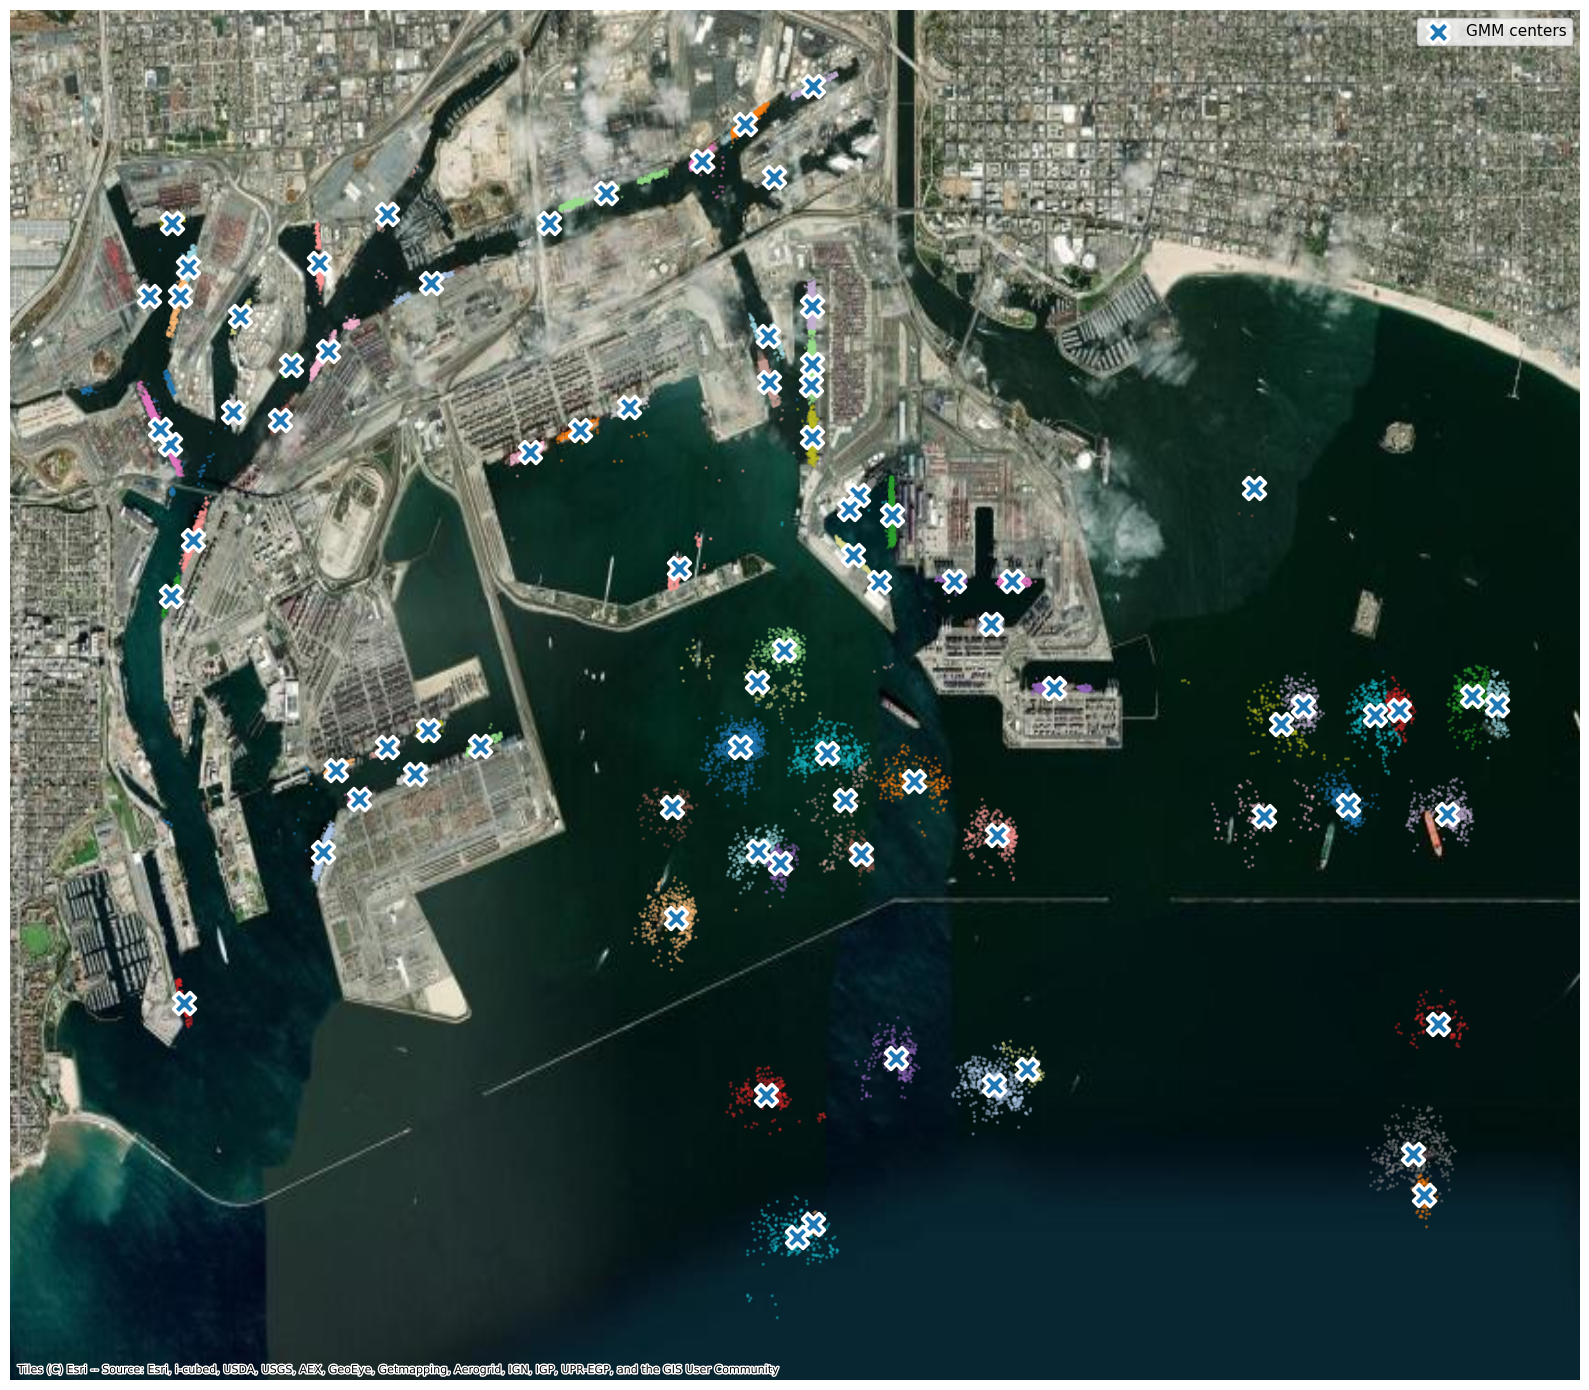

CPU times: total: 1.86 s
Wall time: 2.43 s


In [16]:
%%time
STD_JSON = "standardization_params.json"

with open(STD_JSON, "r") as f:
    std = json.load(f)

plot_coords = np.asarray(all_data_coords, dtype=float)
plot_labels = np.asarray(FINAL_GMM["labels"], dtype=int)

MAX_PLOT_POINTS = 20000
if plot_coords.shape[0] > MAX_PLOT_POINTS:
    idx = np.random.choice(plot_coords.shape[0], MAX_PLOT_POINTS, replace=False)
    plot_coords = plot_coords[idx]
    plot_labels = plot_labels[idx]

lon = plot_coords[:, 0] * float(std["lon_std"]) + float(std["lon_mean"])
lat = plot_coords[:, 1] * float(std["lat_std"]) + float(std["lat_mean"])

mu = np.asarray(FINAL_GMM["mu"], dtype=float)
mu_lon = mu[:, 0] * float(std["lon_std"]) + float(std["lon_mean"])
mu_lat = mu[:, 1] * float(std["lat_std"]) + float(std["lat_mean"])

R = 6378137.0
x = np.deg2rad(lon) * R
y = np.log(np.tan(np.pi / 4.0 + np.deg2rad(lat) / 2.0)) * R
mx = np.deg2rad(mu_lon) * R
my = np.log(np.tan(np.pi / 4.0 + np.deg2rad(mu_lat) / 2.0)) * R

fig, ax = plt.subplots(figsize=(16, 14))
ax.scatter(x, y, c=plot_labels, cmap="tab20", s=2, alpha=0.35, rasterized=True)
ax.scatter(mx, my, marker="X", s=250, edgecolors="white", linewidths=2.5, label="GMM centers", zorder=6)

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)
ax.set_axis_off()
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
